# Spiral Wave Induction base on Given Phase Map

This tutorial illustraits how induce reentry in specific region if the heart

Running BuenoOrovio on [335, 335] Grid: 100%|██████████| 3000/3000 [00:06<00:00, 473.80it/s]


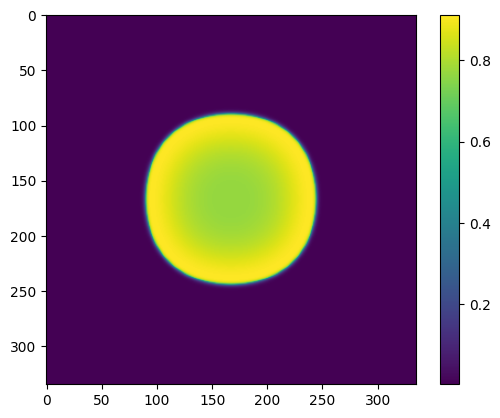

In [1]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np


model_parameters = {
    "D_model": 0.188,
    "tau_v1_m": 41.857,
    "tau_v2_m": 1150.0,
    "tau_v_p": 1.7,
    "tau_w1_m": 138.69,
    "tau_w2_m": 62.341,
    "tau_w_p": 177.41,
    "tau_fi": 0.045,
    "tau_o1": 410.0,
    "tau_o2": 64.914,
    "tau_so1": 115,
    "tau_so2": 6.5,
    "tau_s1": 11.457,
    "tau_s2": 53.902,
    "tau_si": 7.802,
    "tau_w_inf": 0.050,
    "theta_v": 0.35,
    "theta_w": 0.328,
    "theta_v_m": 0.126,
    "theta_o": 0.00005,
    "u_w_m": 0.055,
    "u_o": 0.0,
    "u_u": 0.9205,
    "u_so": 0.332,
    "u_s": 0.792,
    "k_w_m": 202.66,
    "k_so": 1.386,
    "k_s": 1.226,
    "w_inf_": 1.0
    }

stim_prepacing = fw.StimPrepacing(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=30, cycle_length=500, duration=1, curr_value=0.5)

cardiac_model = fw.BuenoOrovio()
cardiac_model.set_parameters(model_parameters)
cardiac_model.prepacing(stim_prepacing)


# create a tissue of size 400x400 with cardiomycytes:
n = 335
tissue = fw.CardiacTissueGrid([n, n], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=n//2 - 3, x_max=n//2 + 3,
                                           y_min=n//2 - 3, y_max=n//2 + 3))

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 30
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.cardiac_model = cardiac_model

# run the model:
simulation.run()

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
plt.figure()
plt.imshow(simulation.cardiac_model.output("u"))
plt.colorbar()
plt.show()

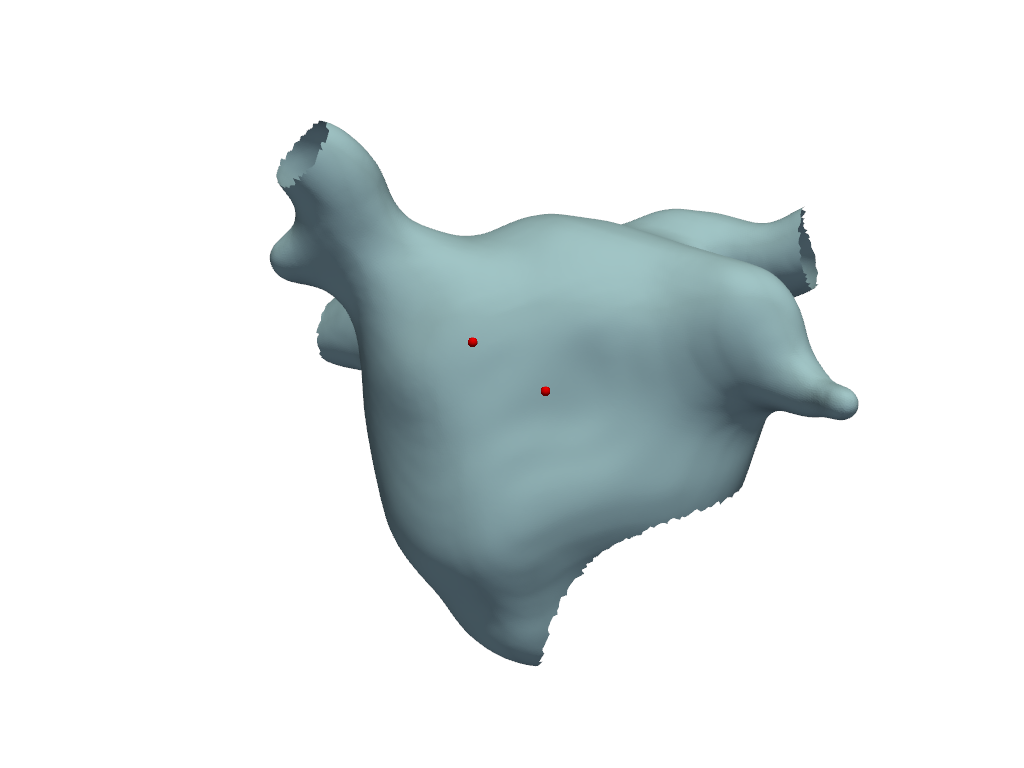

In [2]:
from pathlib import Path
import numpy as np
import pyvista as pv
import numpy as np


path = Path("/Users/arstanbekokenov/Projects/Finitewave/examples/data/atrial_mesh")
vtk_mesh = pv.read(path / "Mesh_31475951.vtk")

camera_position = [
    (29.5, 169.2, 68.3),
    (-13.3, -26.5, 52.2),
    (0.299, -0.142, 0.943)
]

coords = vtk_mesh.points / 1000
elems = vtk_mesh.faces.reshape(-1, 4)[:, 1:4]
fibers = vtk_mesh.cell_data['fiber_endo']

point_ids = [106429, 57035]

faces = np.hstack([[3, *tri] for tri in elems])
mesh = pv.PolyData(coords, faces)

# set static plot
pv.set_jupyter_backend('static') 

pl = pv.Plotter()
pl.add_mesh(mesh, show_edges=False)
pl.add_points(coords[point_ids], color='red', point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()

## Generate phase map

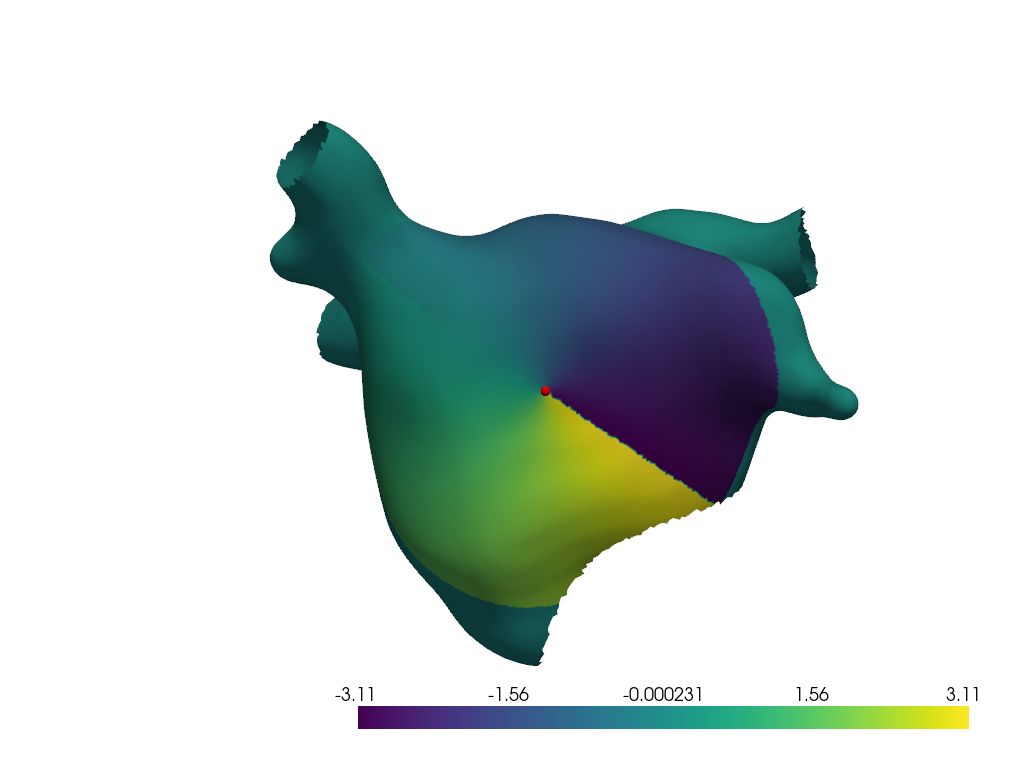

In [3]:
from scipy import spatial


def find_points_within_radius(mesh, point, radius):
    """
    Find indices of points in the mesh that are within a given radius of a specified point.

    Parameters
    ----------
    mesh: pyvista.PolyData
        The input mesh containing the points to search.
    point: array-like of shape (3,)
        The reference point from which to measure distances.
    radius: float
        The radius within which to search for points.

    Returns
    -------  
    indices: list of int
        A list of indices of points in the mesh that are within the specified radius of
        the reference point.
    """
    tree = spatial.cKDTree(mesh.points)
    indices = tree.query_ball_point(point, radius)
    return indices


def project_local_per_vector(x, V, normals, eps=1e-12):
    """
    Project vectors V onto a local coordinate system defined by x and the normals.

    Parameters
    ----------
    x: array-like of shape (3,)
        The reference vector defining the local x-axis.
    V: array-like of shape (N, 3)
        The vectors to be projected.
    normals: array-like of shape (N, 3)
        The normal vectors at each point corresponding to V.
    eps: float, optional
        A small value to handle numerical stability in case of parallel vectors.

    Returns
    -------
    V_out: array of shape (N, 2)
        The projected vectors in the local coordinate system
    """
    x_hat = x / np.linalg.norm(x)
    vx = V @ x_hat
    Y = V - vx[:, None] * x_hat

    vy = np.linalg.norm(Y, axis=1)
    vy[vy < eps] = 0.0
    
    n = np.cross(x_hat, V)
    n_norm = np.linalg.norm(n, axis=1)
    n_norm[n_norm < eps] = 1.0
    n_hat = n / n_norm[:, None]

    sign = np.einsum('ij,ij->i', n_hat, normals)
    vy *= np.sign(sign)

    V_out = np.stack([vx, vy], axis=1)
    return V_out


inds = find_points_within_radius(mesh, coords[point_ids[0]], 30)
mesh = mesh.compute_normals(inplace=True)
normals_0 = mesh.point_normals[inds]

vectors_0 = mesh.points[inds] - coords[point_ids[0]]
x_axis_0 = mesh.points[point_ids[1]] - coords[point_ids[0]]

vectors_0 = project_local_per_vector(x_axis_0, vectors_0, normals_0)

angles_0 = np.arctan2(vectors_0[:, 1], vectors_0[:, 0])

phase_map = np.zeros(mesh.n_points)
phase_map[inds] = angles_0

pl = pv.Plotter()
pl.add_mesh(mesh, scalars=phase_map, show_edges=False)
pl.add_points(coords[point_ids[0]], color='red', point_size=10, render_points_as_spheres=True)
pl.camera_position = camera_position
pl.show()


## Generate state variables for each phase values

Running BuenoOrovio on [20, 5] Grid: 100%|██████████| 30000/30000 [00:00<00:00, 37905.45it/s]


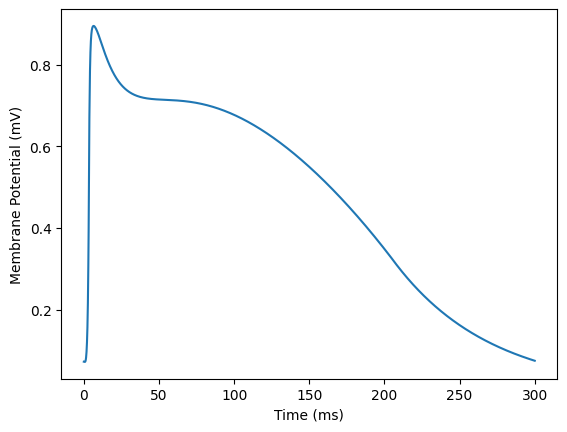

In [4]:

from pathlib import Path
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np


# create a tissue of size 50x10 to collect the state variables.
n, m = 20, 5
tissue = fw.CardiacTissueGrid([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=100, duration=2,
                                           x_min=0, x_max=1, y_min=0, y_max=m))

stim_prepacing = fw.StimPrepacing(dt=0.005)
stim_prepacing.add_stim(n_beats=30, cycle_length=500., curr_value=20., duration=2.)
stim_prepacing.add_stim(n_beats=30, cycle_length=300., curr_value=20., duration=2.)

model = fw.BuenoOrovio()
model.set_parameters(model_parameters)
model.prepacing(stim_prepacing)

state_tracker = fw.MultiVariableTracker(node_inds=[(n//2, m//2)], step=10, start_time=0)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(state_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="numba")
simulation.dt = 0.01
simulation.t_max = 300
simulation.cardiac_model = model
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

state_vars = {}
state_map = np.digitize(phase_map, bins=np.linspace(-np.pi, np.pi, len(state_tracker.tracking_times))) - 1
for var_name in model.state_vars:
    tracked_values = state_tracker.output[var_name]
    var_array = tracked_values[state_map]
    state_vars[var_name] = var_array


plt.figure()
plt.plot(state_tracker.tracking_times, state_tracker.output["u"])
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.show()


## Run simulation

numba


Running BuenoOrovio on Triangle Elements: 100%|██████████| 1000/1000 [00:15<00:00, 63.48it/s]


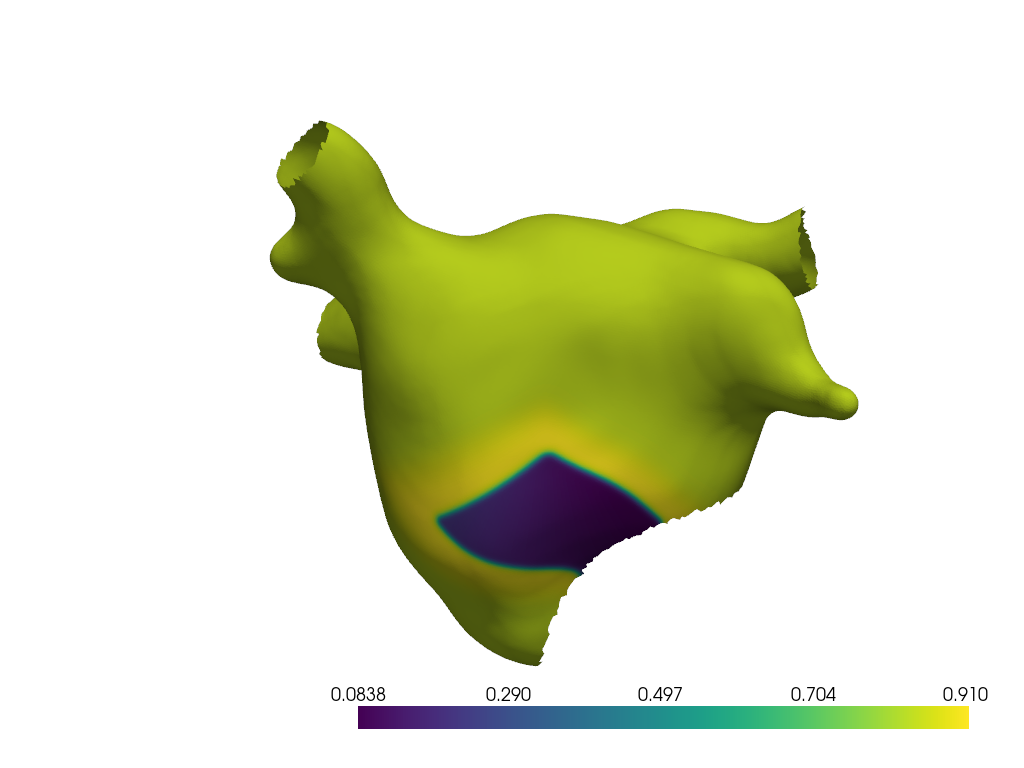

In [11]:
tissue = fw.CardiacTissueElements(coords, elems, "Triangle")

model = fw.BuenoOrovio()
model.set_parameters(model_parameters)
model.prepacing(stim_prepacing)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(backend="numba")
simulation.dt = 0.01
simulation.t_max = 10
simulation.cardiac_model = model
simulation.cardiac_tissue = tissue

simulation.initialize()
simulation.cardiac_model.set_variables(state_vars)
# run the model:
simulation.run(initialize=False)

# show the potential map at the end of calculations:
pl = pv.Plotter()
pl.add_mesh(mesh, scalars=model.u, show_edges=False)
pl.camera_position = camera_position
pl.show()

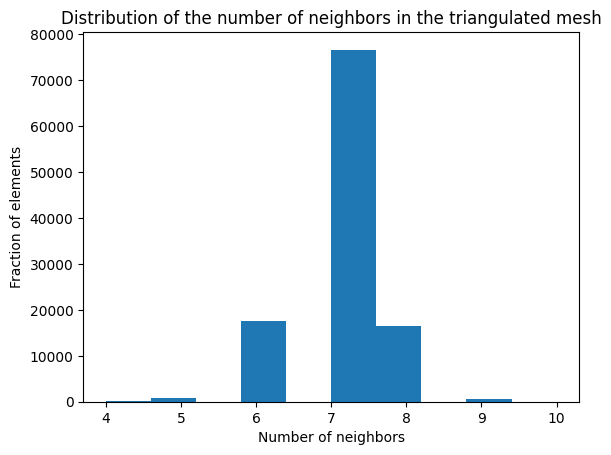

In [8]:
import matplotlib.pyplot as plt
K = simulation.diffusion_model.weights[0]
# show the distribution of the number of neighbors (non-zero entries in the stiffness matrix):
plt.figure()
plt.hist(K.getnnz(axis=1))
plt.xlabel("Number of neighbors")
plt.ylabel("Fraction of elements")
plt.title("Distribution of the number of neighbors in the triangulated mesh")
plt.show()